# Gallstone Data Processing in Jupyter Notebook
This notebook processes the datasets, and splitting subjects into groups for further analysis.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

## Comprehensive Box Plots for All Features

Let's create box plots for all 39 numeric features to get a complete overview of outliers across the entire dataset.

Total numeric features: 38
Features: ['Age', 'Gender', 'Comorbidity', 'Coronary Artery Disease (CAD)', 'Hypothyroidism'] ... (showing first 5)


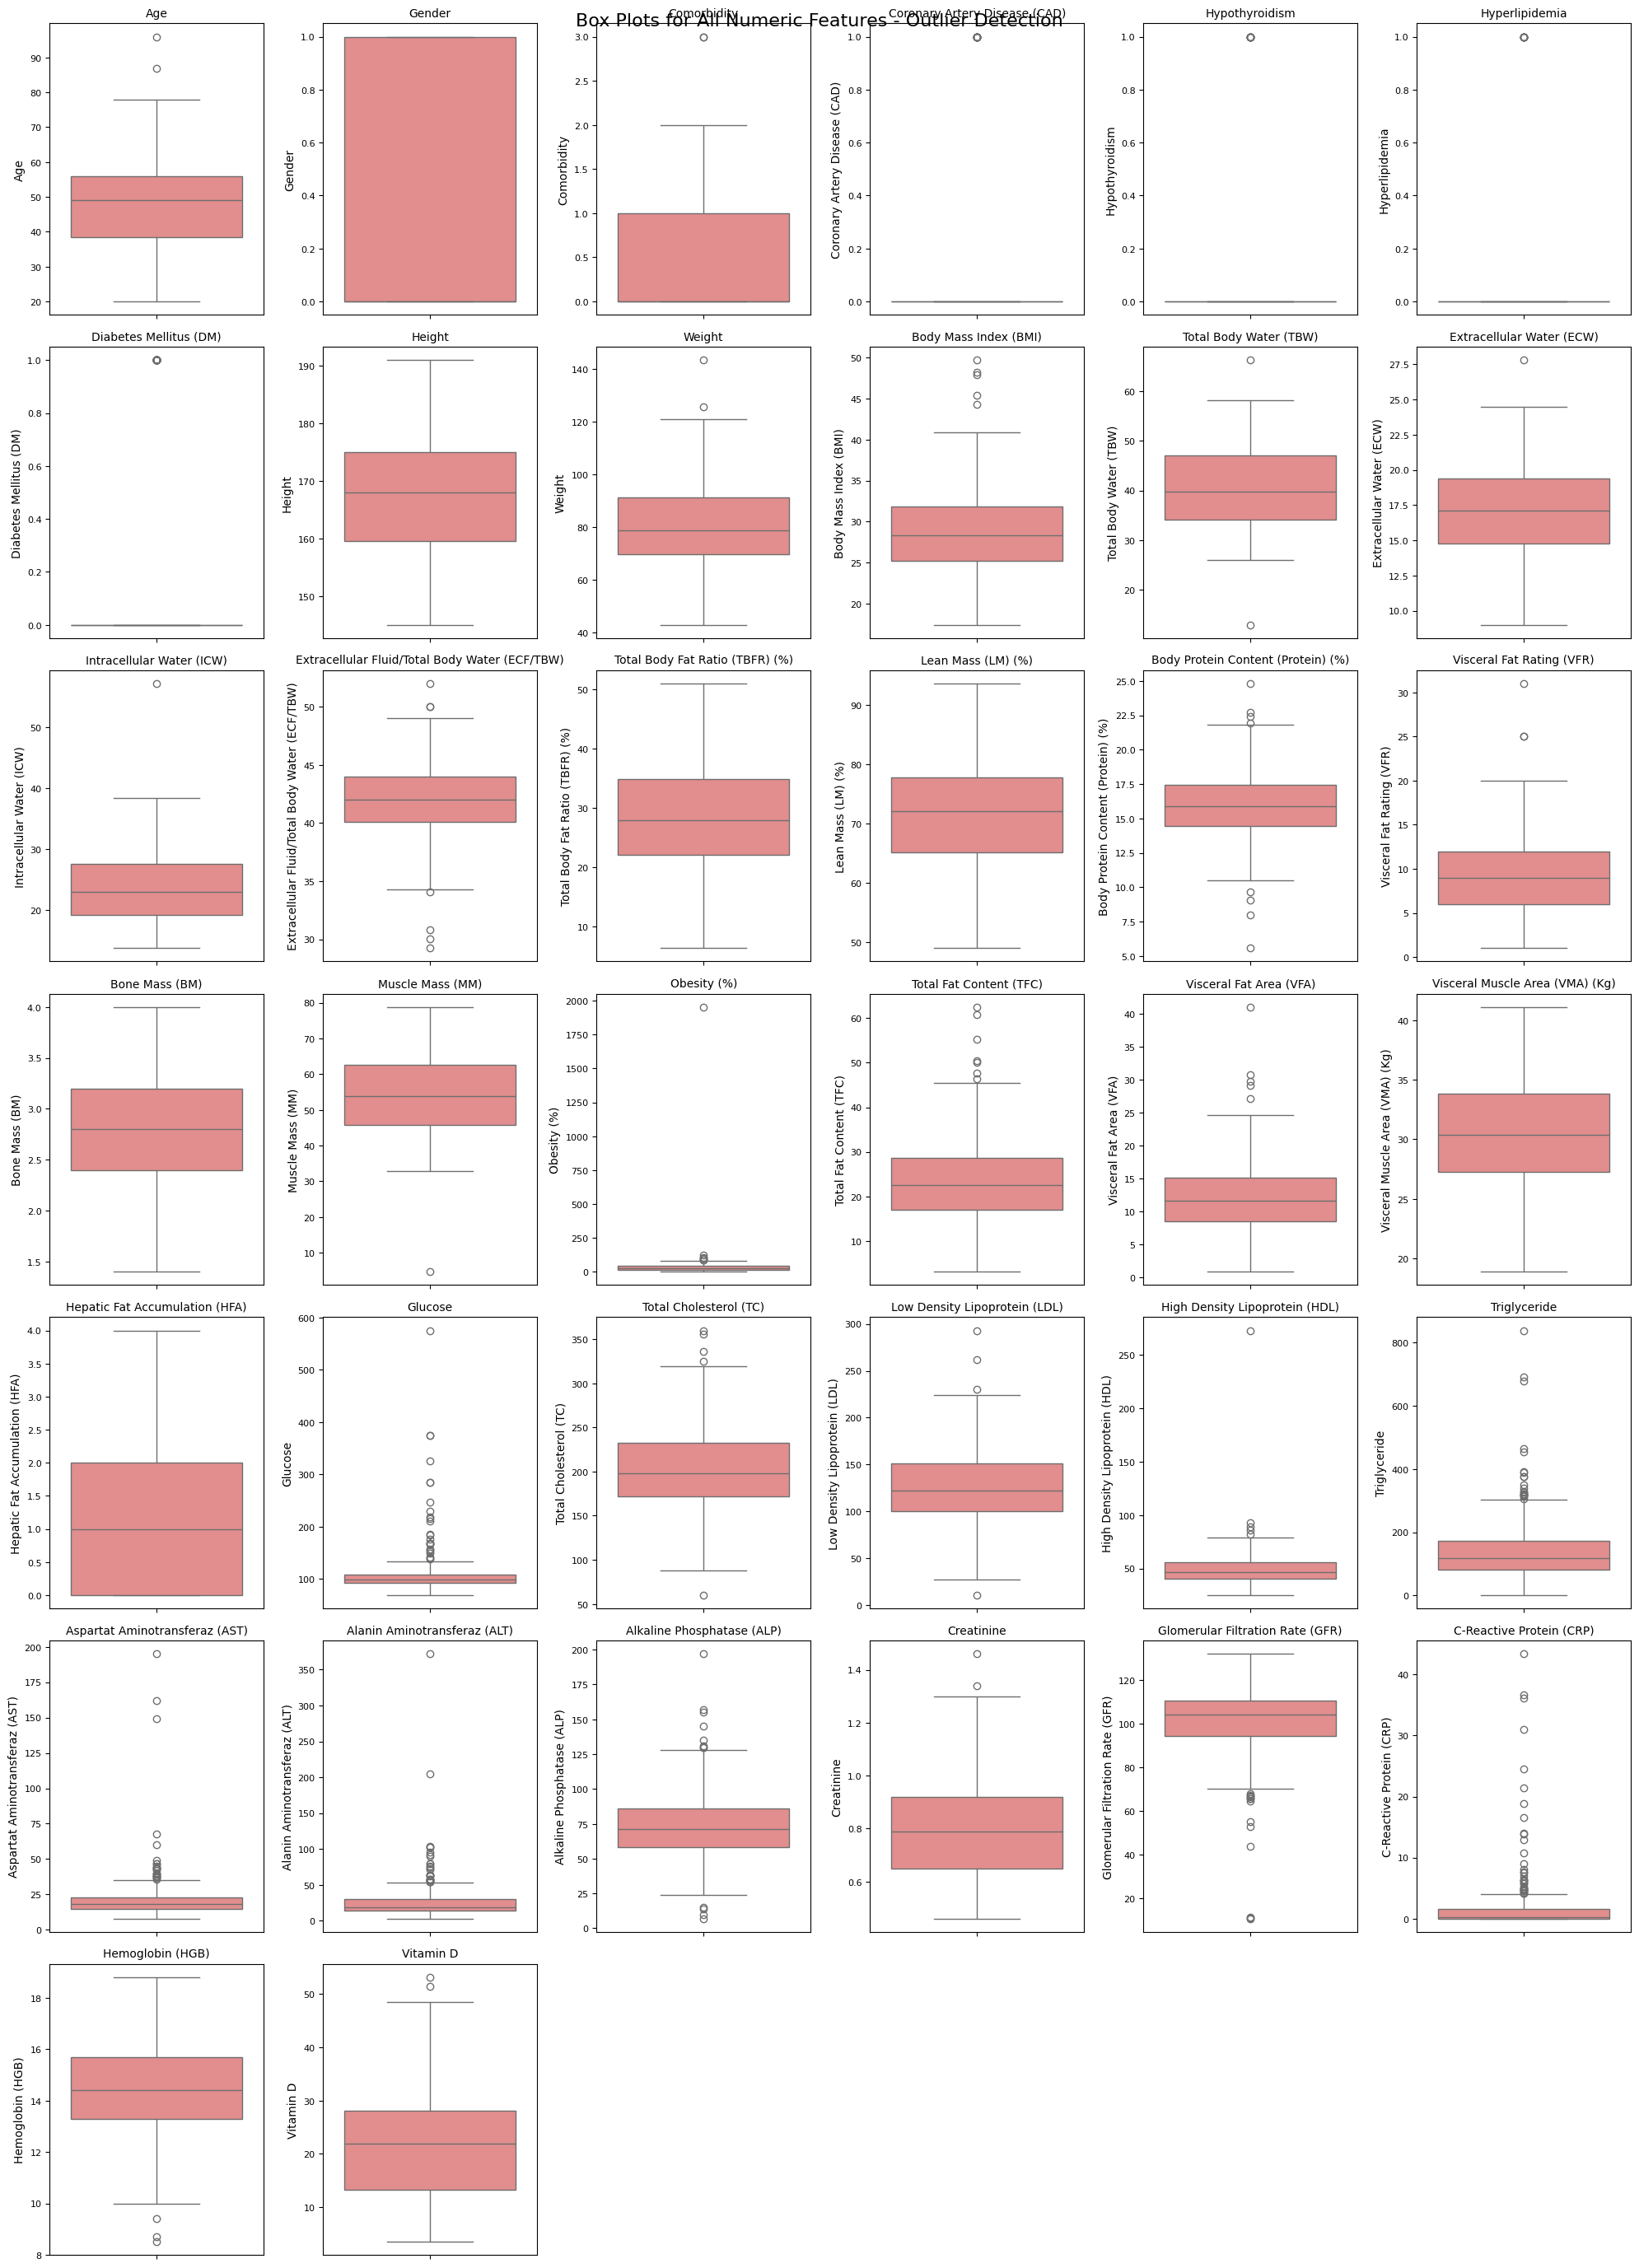

In [3]:
df = pd.read_csv("../data/raw/dataset-uci.csv")
# Get all numeric columns (exclude categorical and target)
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_columns.remove('Gallstone Status')  # Remove target variable

print(f"Total numeric features: {len(numeric_columns)}")
print("Features:", numeric_columns[:5], "... (showing first 5)")

# Create comprehensive box plots for all numeric features
n_cols = 6  # Number of columns in subplot grid
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols  # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()  # Flatten for easy indexing

for i, col in enumerate(numeric_columns):
    sns.boxplot(y=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"{col}", fontsize=10)
    axes[i].tick_params(axis='both', labelsize=8)

# Hide empty subplots
for j in range(len(numeric_columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Box Plots for All Numeric Features - Outlier Detection", fontsize=16)
plt.tight_layout()
plt.show()

## Outlier Detection and Removal Function

Here's a comprehensive function to detect and remove outliers using the IQR method.

In [4]:
# First, let's identify binary features (only values 0 and 1)
def identify_binary_features(df):
    """
    Identify columns that contain only binary values (0 and 1).
    """
    binary_features = []
    
    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        unique_values = df[col].dropna().unique()
        if len(unique_values) == 2 and set(unique_values) == {0, 1}:
            binary_features.append(col)
        elif len(unique_values) <= 2 and all(val in [0, 1] for val in unique_values):
            binary_features.append(col)
    
    return binary_features

# Identify binary features in your dataset
binary_features = identify_binary_features(df)
print("=== BINARY FEATURES DETECTED ===")
print(f"Found {len(binary_features)} binary features:")
for feature in binary_features:
    unique_vals = sorted(df[feature].unique())
    print(f"  {feature}: {unique_vals}")

# Get continuous features (exclude binary features and target)
continuous_features = [col for col in numeric_columns if col not in binary_features]
print(f"\n=== CONTINUOUS FEATURES FOR OUTLIER REMOVAL ===")
print(f"Found {len(continuous_features)} continuous features:")
print("First 10:", continuous_features[:10])
if len(continuous_features) > 10:
    print(f"... and {len(continuous_features) - 10} more")

=== BINARY FEATURES DETECTED ===
Found 6 binary features:
  Gallstone Status: [np.int64(0), np.int64(1)]
  Gender: [np.int64(0), np.int64(1)]
  Coronary Artery Disease (CAD): [np.int64(0), np.int64(1)]
  Hypothyroidism: [np.int64(0), np.int64(1)]
  Hyperlipidemia: [np.int64(0), np.int64(1)]
  Diabetes Mellitus (DM): [np.int64(0), np.int64(1)]

=== CONTINUOUS FEATURES FOR OUTLIER REMOVAL ===
Found 33 continuous features:
First 10: ['Age', 'Comorbidity', 'Height', 'Weight', 'Body Mass Index (BMI)', 'Total Body Water (TBW)', 'Extracellular Water (ECW)', 'Intracellular Water (ICW)', 'Extracellular Fluid/Total Body Water (ECF/TBW)', 'Total Body Fat Ratio (TBFR) (%)']
... and 23 more


In [5]:
def detect_outliers_iqr(df, columns=None, multiplier=1.5, exclude_binary=True):
    """
    Detect outliers using the IQR method for specified columns.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The input dataframe
    columns : list, optional
        List of column names to check for outliers. If None, uses continuous features only.
    multiplier : float, default=1.5
        IQR multiplier (1.5 is standard, 3.0 is more conservative)
    exclude_binary : bool, default=True
        Whether to exclude binary features (0/1) from outlier detection
    
    Returns:
    --------
    dict : Dictionary with column names as keys and outlier indices as values
    """
    if columns is None:
        # Get all numeric columns
        all_numeric = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
        
        if exclude_binary:
            # Exclude binary features and target variable
            binary_features = identify_binary_features(df)
            columns = [col for col in all_numeric if col not in binary_features and col != 'Gallstone Status']
        else:
            columns = [col for col in all_numeric if col != 'Gallstone Status']
    
    outlier_indices = {}
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Skip if IQR is 0 (all values are the same)
        if IQR == 0:
            outlier_indices[col] = []
            continue
            
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        # Find outlier indices
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_indices[col] = outliers.tolist()
    
    return outlier_indices

def remove_outliers_iqr(df, columns=None, multiplier=1.5, method='any', exclude_binary=True):
    """
    Remove outliers from dataframe using IQR method.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The input dataframe
    columns : list, optional
        List of column names to check for outliers. If None, uses continuous features only.
    multiplier : float, default=1.5
        IQR multiplier (1.5 is standard, 3.0 is more conservative)
    method : str, default='any'
        'any': Remove rows with outliers in ANY column
        'all': Remove rows with outliers in ALL columns
        'per_column': Remove outliers separately for each column (not recommended)
    exclude_binary : bool, default=True
        Whether to exclude binary features (0/1) from outlier detection
    
    Returns:
    --------
    pandas.DataFrame : Cleaned dataframe with outliers removed
    dict : Summary statistics about removed outliers
    """
    original_shape = df.shape
    
    if columns is None:
        # Get all numeric columns
        all_numeric = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
        
        if exclude_binary:
            # Exclude binary features and target variable
            binary_features = identify_binary_features(df)
            columns = [col for col in all_numeric if col not in binary_features and col != 'Gallstone Status']
        else:
            columns = [col for col in all_numeric if col != 'Gallstone Status']
    
    outlier_indices = detect_outliers_iqr(df, columns, multiplier, exclude_binary)
    
    # Collect summary statistics
    summary = {}
    for col in columns:
        summary[col] = len(outlier_indices[col])
    
    if method == 'any':
        # Remove rows that have outliers in ANY column
        all_outlier_indices = set()
        for indices in outlier_indices.values():
            all_outlier_indices.update(indices)
        
        df_clean = df.drop(index=all_outlier_indices).reset_index(drop=True)
        
    elif method == 'all':
        # Remove rows that have outliers in ALL columns (very conservative)
        if outlier_indices:
            common_outliers = set(outlier_indices[columns[0]])
            for col in columns[1:]:
                common_outliers = common_outliers.intersection(set(outlier_indices[col]))
            df_clean = df.drop(index=common_outliers).reset_index(drop=True)
        else:
            df_clean = df.copy()
    
    elif method == 'per_column':
        # Remove outliers for each column separately (can remove a lot of data)
        df_clean = df.copy()
        for col in columns:
            outliers = outlier_indices[col]
            df_clean = df_clean.drop(index=outliers)
        df_clean = df_clean.reset_index(drop=True)
    
    # Summary statistics
    final_summary = {
        'original_rows': original_shape[0],
        'final_rows': df_clean.shape[0],
        'removed_rows': original_shape[0] - df_clean.shape[0],
        'removal_percentage': (original_shape[0] - df_clean.shape[0]) / original_shape[0] * 100,
        'outliers_per_column': summary,
        'binary_features_excluded': identify_binary_features(df) if exclude_binary else [],
        'features_analyzed': columns
    }
    
    return df_clean, final_summary

# Test the function
print("Outlier Detection and Removal Functions Created!")
print("\\nFunctions available:")
print("- detect_outliers_iqr(): Detect outliers and return indices")
print("- remove_outliers_iqr(): Remove outliers from dataframe")
print("\\nParameters:")
print("- multiplier: 1.5 (standard), 3.0 (conservative)")
print("- method: 'any' (remove if outlier in any column), 'all' (remove if outlier in all columns)")

Outlier Detection and Removal Functions Created!
\nFunctions available:
- detect_outliers_iqr(): Detect outliers and return indices
- remove_outliers_iqr(): Remove outliers from dataframe
\nParameters:
- multiplier: 1.5 (standard), 3.0 (conservative)
- method: 'any' (remove if outlier in any column), 'all' (remove if outlier in all columns)


In [6]:
# Let's first analyze the outliers before removing them (continuous features only)
outlier_info = detect_outliers_iqr(df)  # Uses continuous features by default

print("=== OUTLIER ANALYSIS SUMMARY ===")
print(f"Dataset shape: {df.shape}")
print(f"Analyzing {len(continuous_features)} continuous features")
print(f"Excluded {len(binary_features)} binary features: {binary_features}")
print("\\n--- Outliers per continuous feature ---")

total_outlier_points = 0
for col, indices in outlier_info.items():
    count = len(indices)
    percentage = (count / len(df)) * 100
    total_outlier_points += count
    print(f"{col}: {count} outliers ({percentage:.1f}%)")

print(f"\\n--- Overall Statistics ---")
print(f"Total outlier data points: {total_outlier_points}")

# Find unique rows that contain at least one outlier
all_outlier_rows = set()
for indices in outlier_info.values():
    all_outlier_rows.update(indices)

print(f"Unique rows with at least one outlier: {len(all_outlier_rows)} ({len(all_outlier_rows)/len(df)*100:.1f}%)")

# Show features with most outliers
outlier_counts = {col: len(indices) for col, indices in outlier_info.items()}
top_outlier_features = sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)[:10]

print("\\n--- Top 10 features with most outliers ---")
for col, count in top_outlier_features:
    print(f"{col}: {count} outliers")

=== OUTLIER ANALYSIS SUMMARY ===
Dataset shape: (319, 39)
Analyzing 33 continuous features
Excluded 6 binary features: ['Gallstone Status', 'Gender', 'Coronary Artery Disease (CAD)', 'Hypothyroidism', 'Hyperlipidemia', 'Diabetes Mellitus (DM)']
\n--- Outliers per continuous feature ---
Age: 2 outliers (0.6%)
Comorbidity: 2 outliers (0.6%)
Height: 0 outliers (0.0%)
Weight: 2 outliers (0.6%)
Body Mass Index (BMI): 5 outliers (1.6%)
Total Body Water (TBW): 2 outliers (0.6%)
Extracellular Water (ECW): 1 outliers (0.3%)
Intracellular Water (ICW): 1 outliers (0.3%)
Extracellular Fluid/Total Body Water (ECF/TBW): 7 outliers (2.2%)
Total Body Fat Ratio (TBFR) (%): 0 outliers (0.0%)
Lean Mass (LM) (%): 0 outliers (0.0%)
Body Protein Content (Protein) (%): 8 outliers (2.5%)
Visceral Fat Rating (VFR): 3 outliers (0.9%)
Bone Mass (BM): 0 outliers (0.0%)
Muscle Mass (MM): 1 outliers (0.3%)
Obesity (%): 7 outliers (2.2%)
Total Fat Content (TFC): 7 outliers (2.2%)
Visceral Fat Area (VFA): 5 outliers 

In [8]:
# Now let's demonstrate the outlier removal function (continuous features only)
print("=== OUTLIER REMOVAL DEMONSTRATION ===\\n")

# Option 1: Conservative removal (multiplier=3.0, method='any')
df_clean_conservative, summary_conservative = remove_outliers_iqr(
    df, multiplier=3.0, method='any'  # Uses continuous features by default
)

print("1. CONSERVATIVE REMOVAL (multiplier=3.0, method='any'):")
print(f"   Original rows: {summary_conservative['original_rows']}")
print(f"   Final rows: {summary_conservative['final_rows']}")
print(f"   Removed rows: {summary_conservative['removed_rows']}")
print(f"   Removal percentage: {summary_conservative['removal_percentage']:.1f}%")
print(f"   Binary features excluded: {summary_conservative['binary_features_excluded']}")

# Option 2: Standard removal (multiplier=1.5, method='any')
df_clean_standard, summary_standard = remove_outliers_iqr(
    df, multiplier=1.5, method='any'  # Uses continuous features by default
)

print("\\n2. STANDARD REMOVAL (multiplier=1.5, method='any'):")
print(f"   Original rows: {summary_standard['original_rows']}")
print(f"   Final rows: {summary_standard['final_rows']}")
print(f"   Removed rows: {summary_standard['removed_rows']}")
print(f"   Removal percentage: {summary_standard['removal_percentage']:.1f}%")


print("\\n=== RECOMMENDATION ===")
print("For medical data, I recommend the CONSERVATIVE approach (multiplier=3.0)")
print("This removes only the most extreme outliers while preserving important clinical cases.")
print("Binary features (0/1) are automatically excluded from outlier detection.")

=== OUTLIER REMOVAL DEMONSTRATION ===\n
1. CONSERVATIVE REMOVAL (multiplier=3.0, method='any'):
   Original rows: 319
   Final rows: 262
   Removed rows: 57
   Removal percentage: 17.9%
   Binary features excluded: ['Gallstone Status', 'Gender', 'Coronary Artery Disease (CAD)', 'Hypothyroidism', 'Hyperlipidemia', 'Diabetes Mellitus (DM)']
\n2. STANDARD REMOVAL (multiplier=1.5, method='any'):
   Original rows: 319
   Final rows: 182
   Removed rows: 137
   Removal percentage: 42.9%
\n=== RECOMMENDATION ===
For medical data, I recommend the CONSERVATIVE approach (multiplier=3.0)
This removes only the most extreme outliers while preserving important clinical cases.
Binary features (0/1) are automatically excluded from outlier detection.


## Comprehensive Box Plot Comparison: Before vs After Outlier Removal

Let's visualize the impact of outlier removal across all continuous features for both standard and conservative approaches.

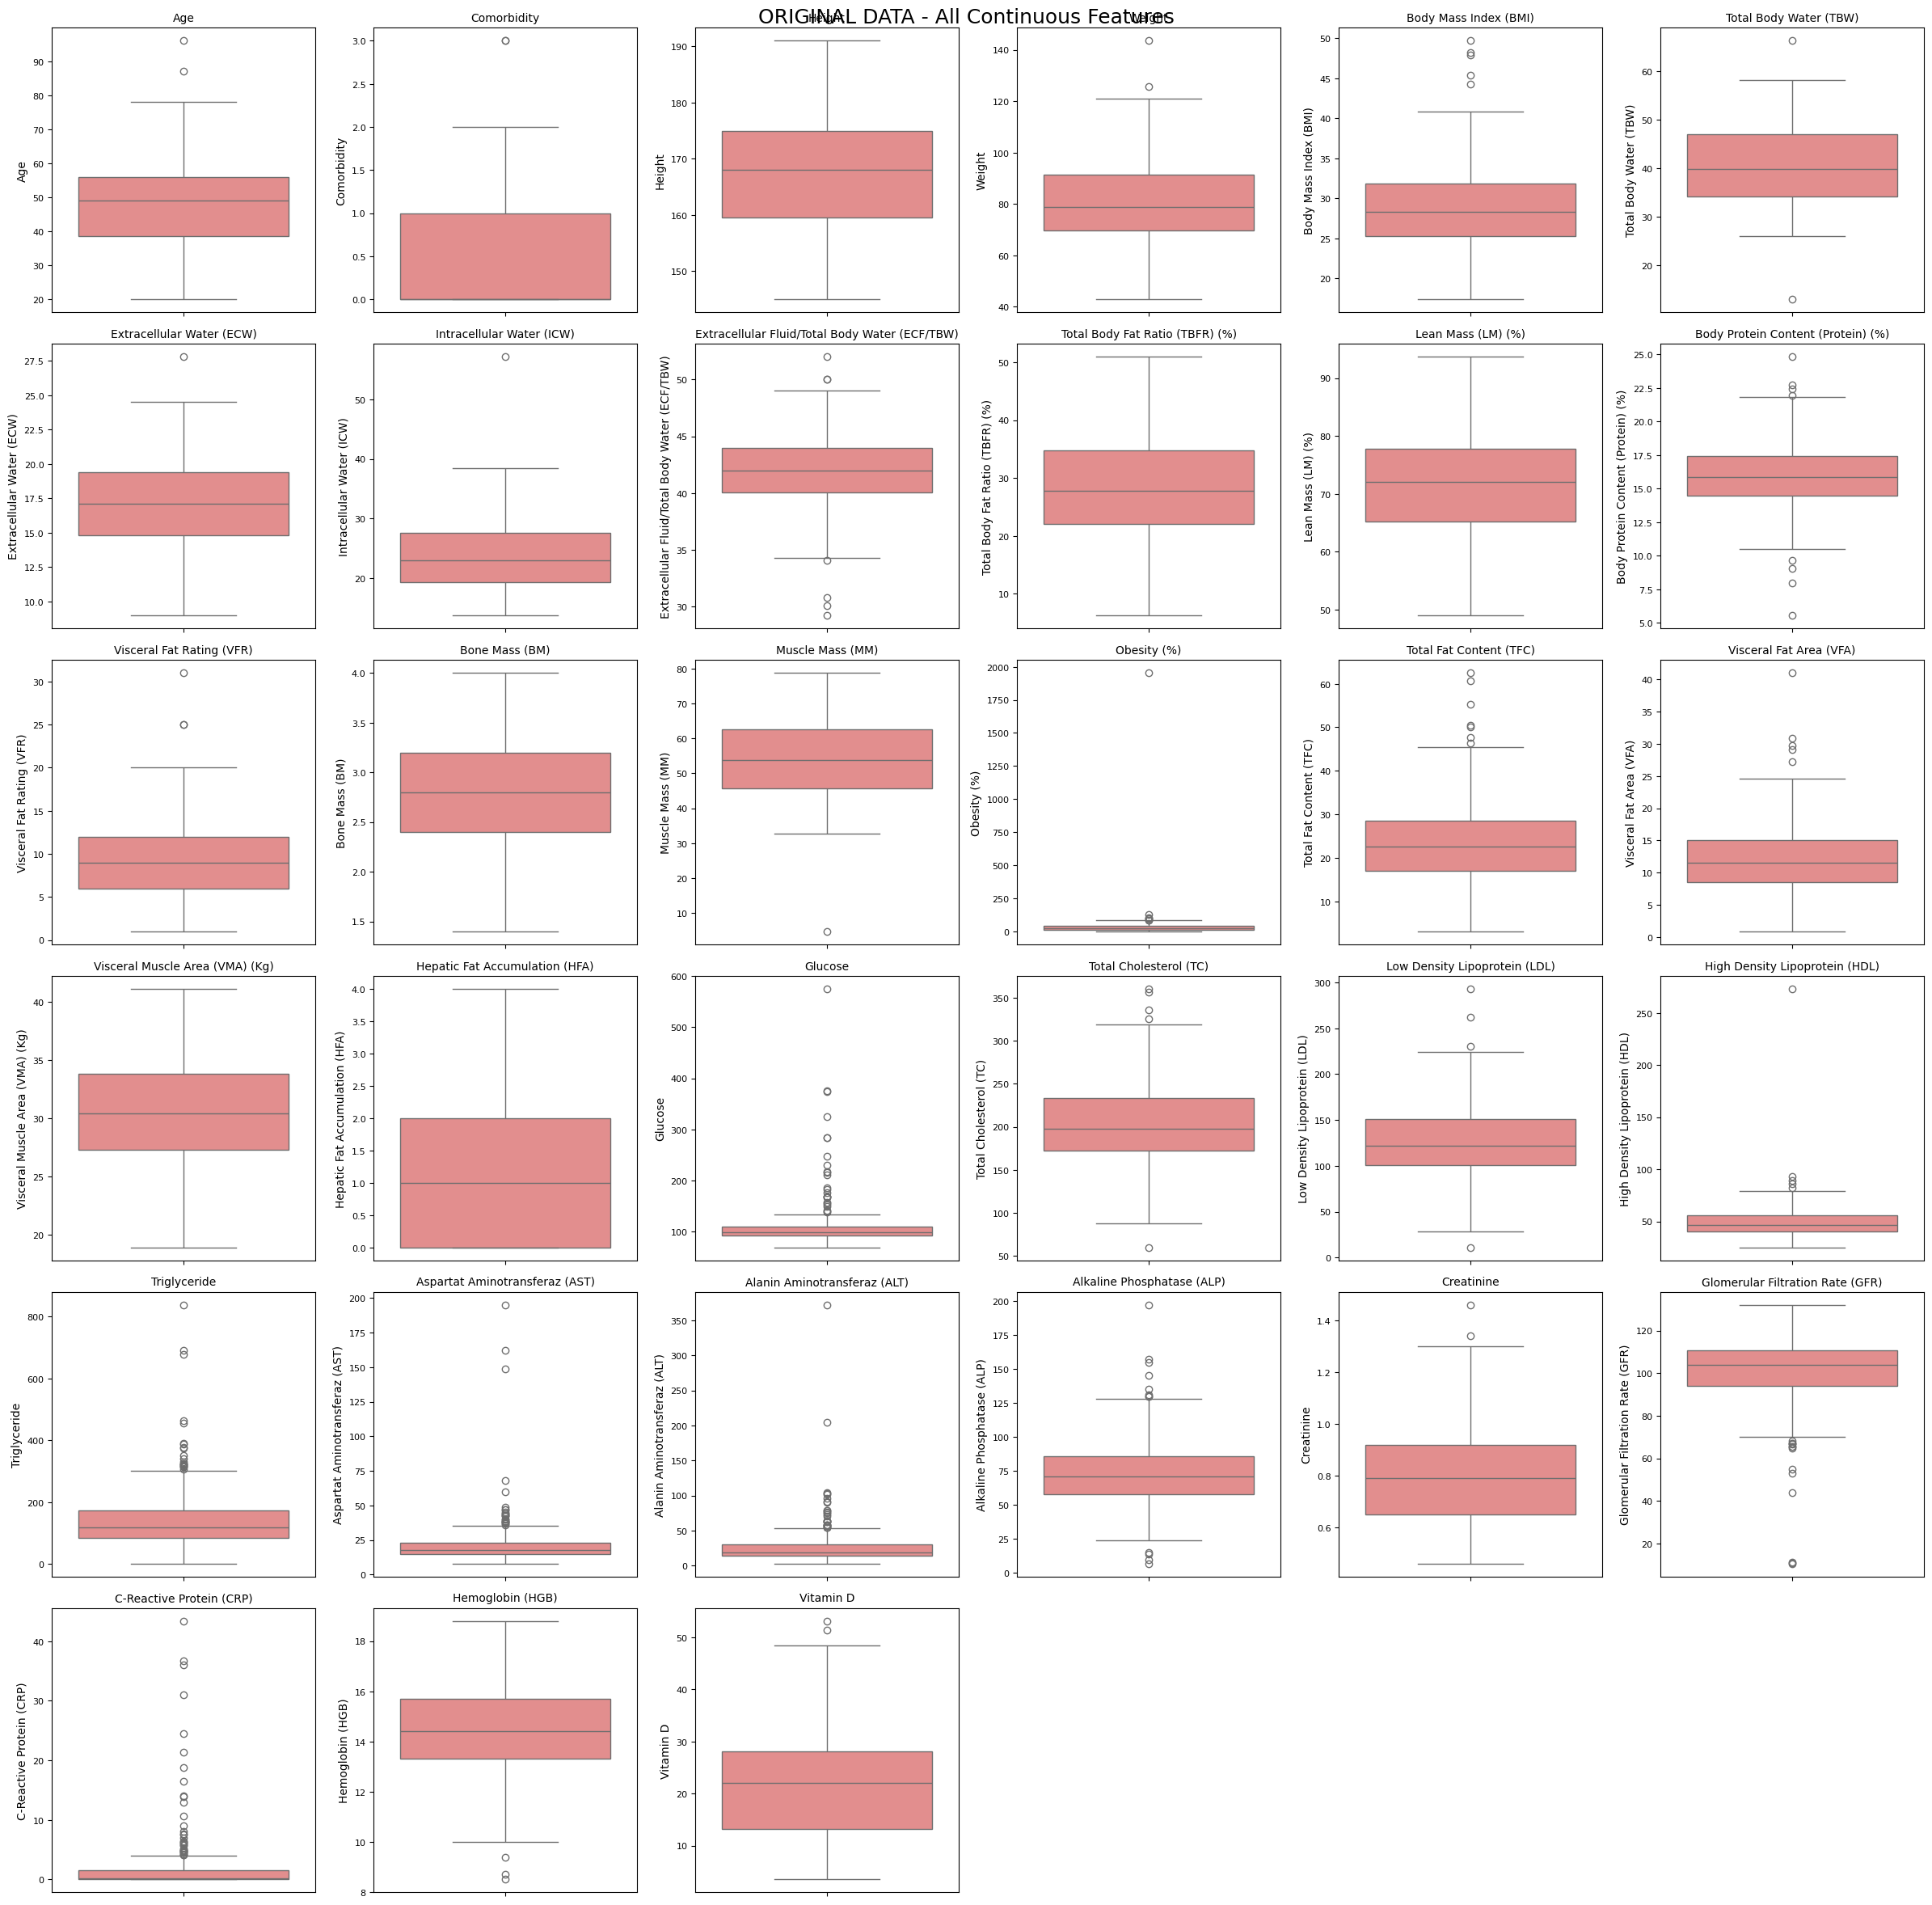

In [10]:
# Create comprehensive box plots for ALL continuous features
# Showing: Original, Conservative Removal, Standard Removal

# We'll create three separate large plots for better visibility
plot_features = continuous_features  # Use all continuous features

# 1. ORIGINAL DATA - All continuous features
n_cols = 6
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_features):
    sns.boxplot(y=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"{col}", fontsize=10)
    axes[i].tick_params(axis='both', labelsize=8)

# Hide empty subplots
for j in range(len(plot_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("ORIGINAL DATA - All Continuous Features", fontsize=18, y=0.98)
plt.tight_layout()
plt.show()

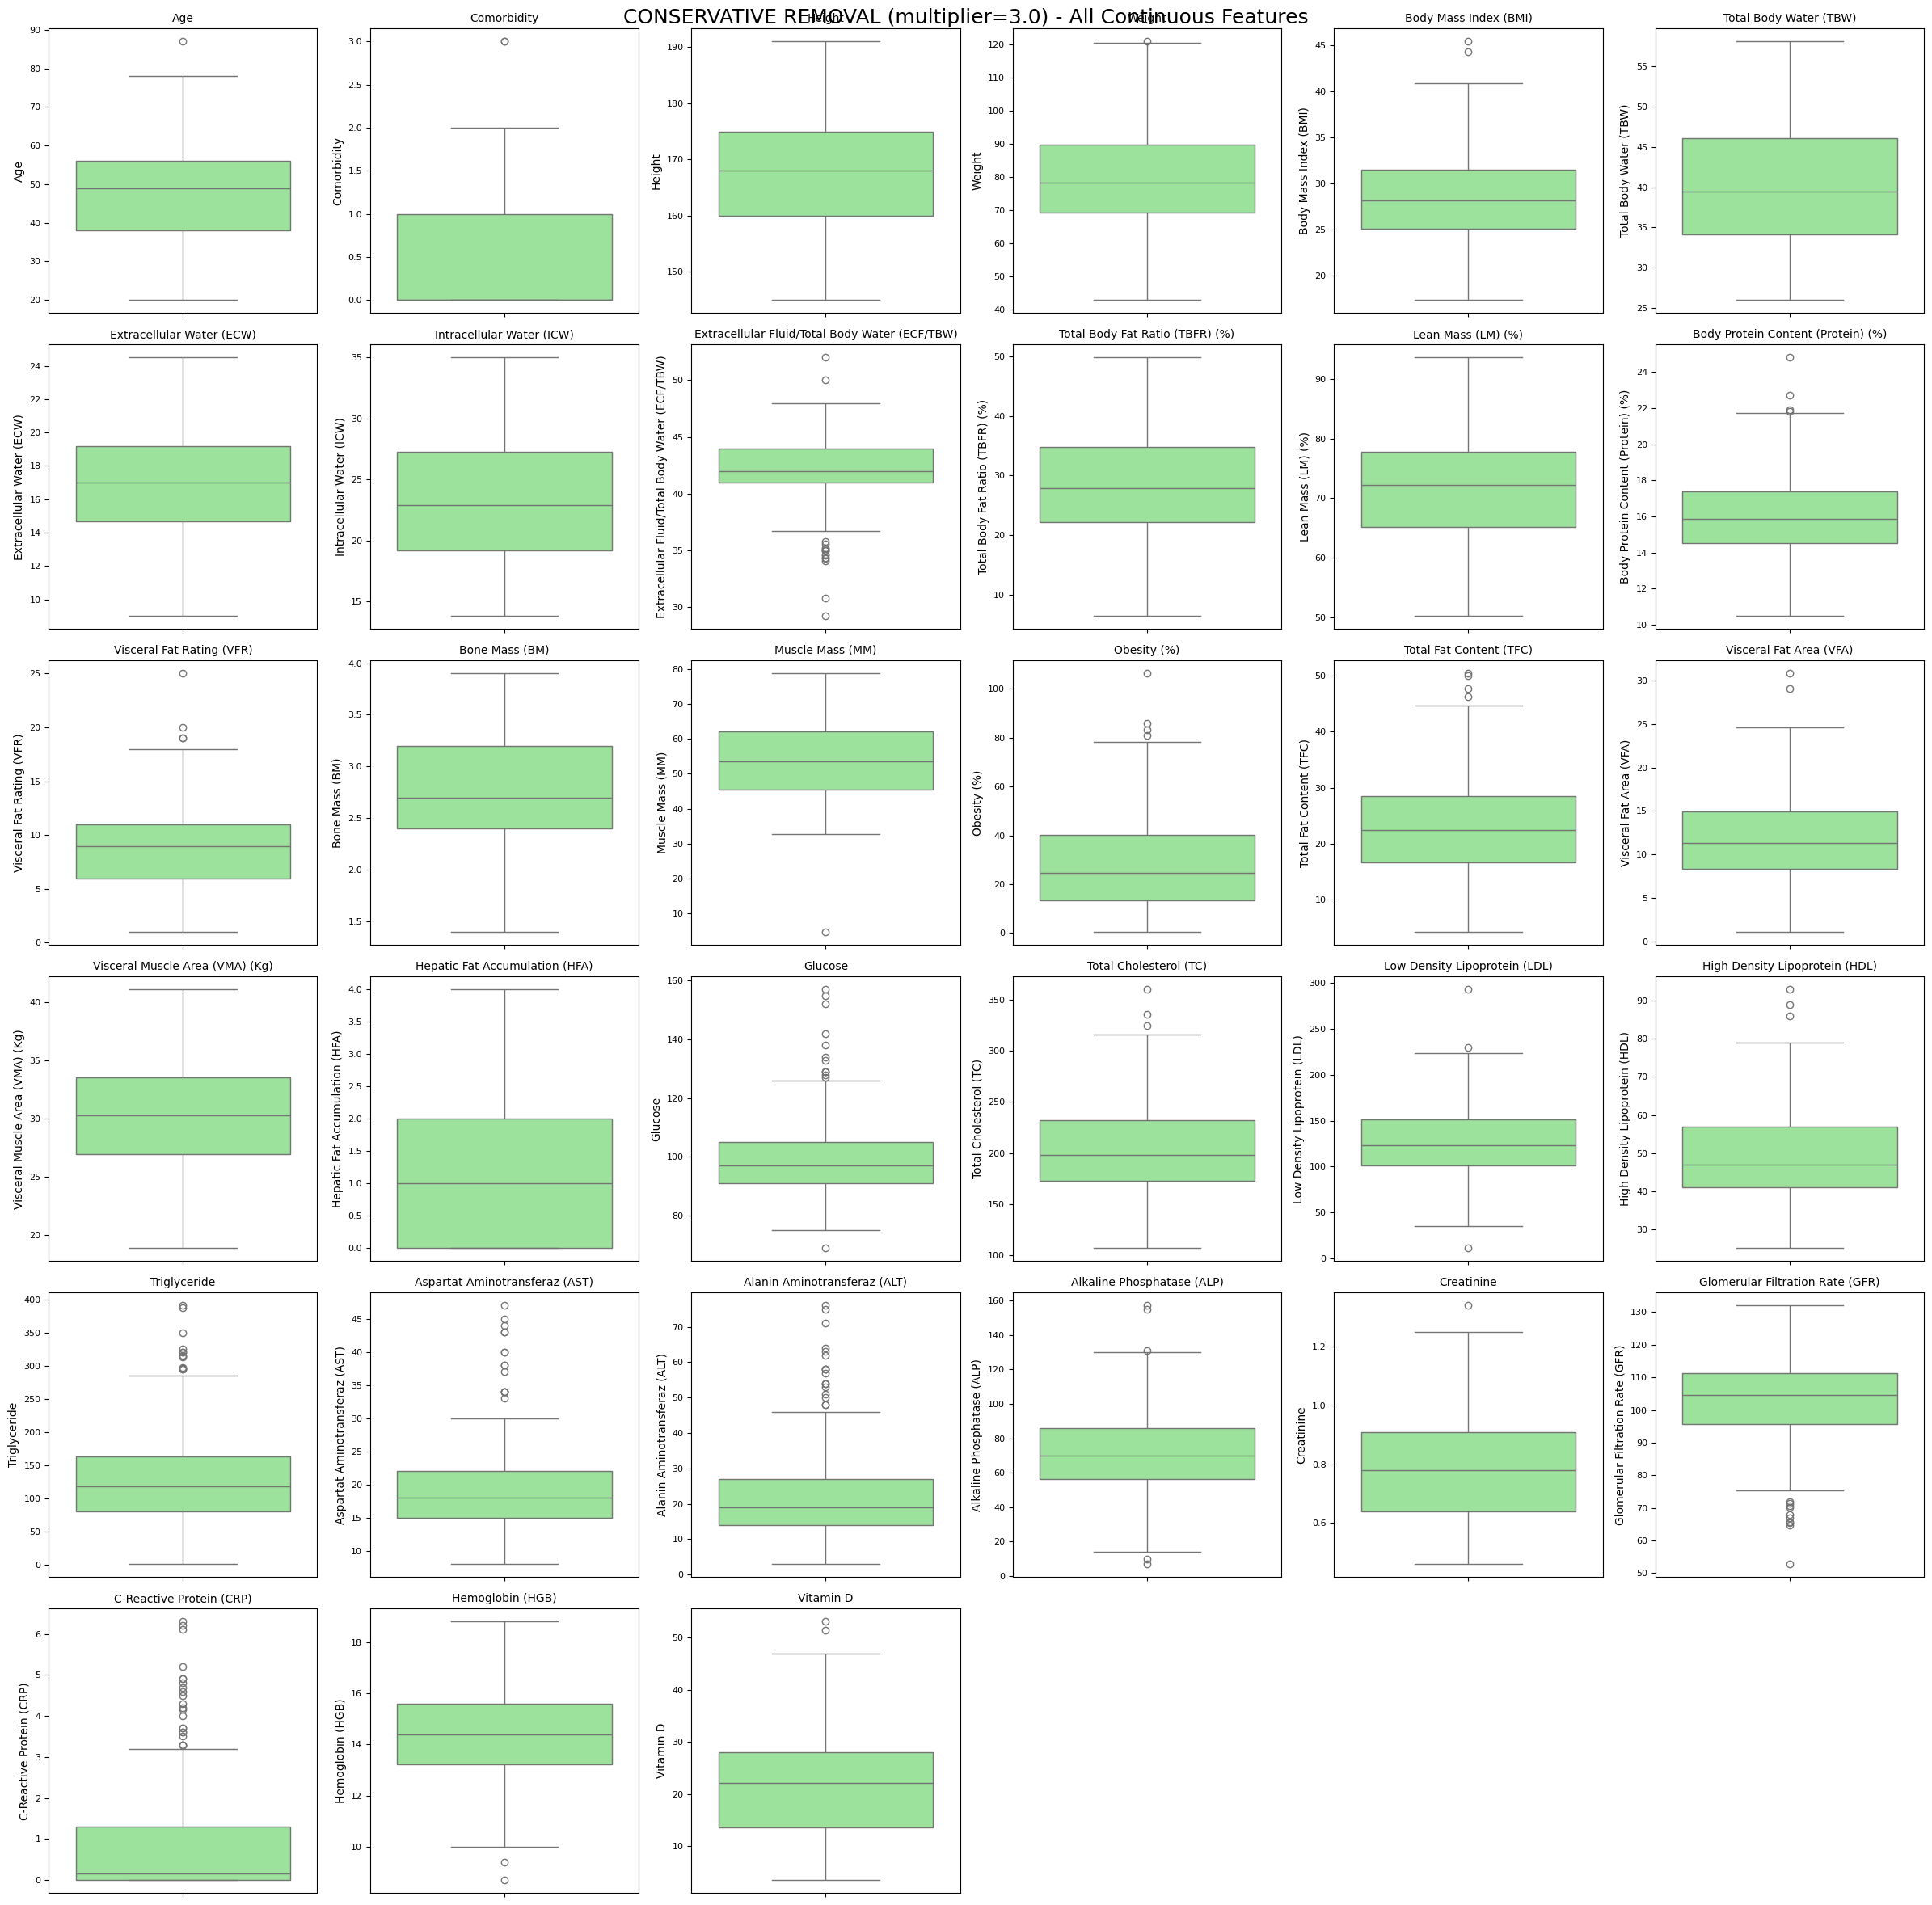

Conservative removal: 57 rows removed (17.9%)


In [11]:
# 2. CONSERVATIVE REMOVAL - All continuous features
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_features):
    sns.boxplot(y=df_clean_conservative[col], ax=axes[i], color="lightgreen")
    axes[i].set_title(f"{col}", fontsize=10)
    axes[i].tick_params(axis='both', labelsize=8)

# Hide empty subplots
for j in range(len(plot_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("CONSERVATIVE REMOVAL (multiplier=3.0) - All Continuous Features", fontsize=18, y=0.98)
plt.tight_layout()
plt.show()

print(f"Conservative removal: {summary_conservative['removed_rows']} rows removed ({summary_conservative['removal_percentage']:.1f}%)")

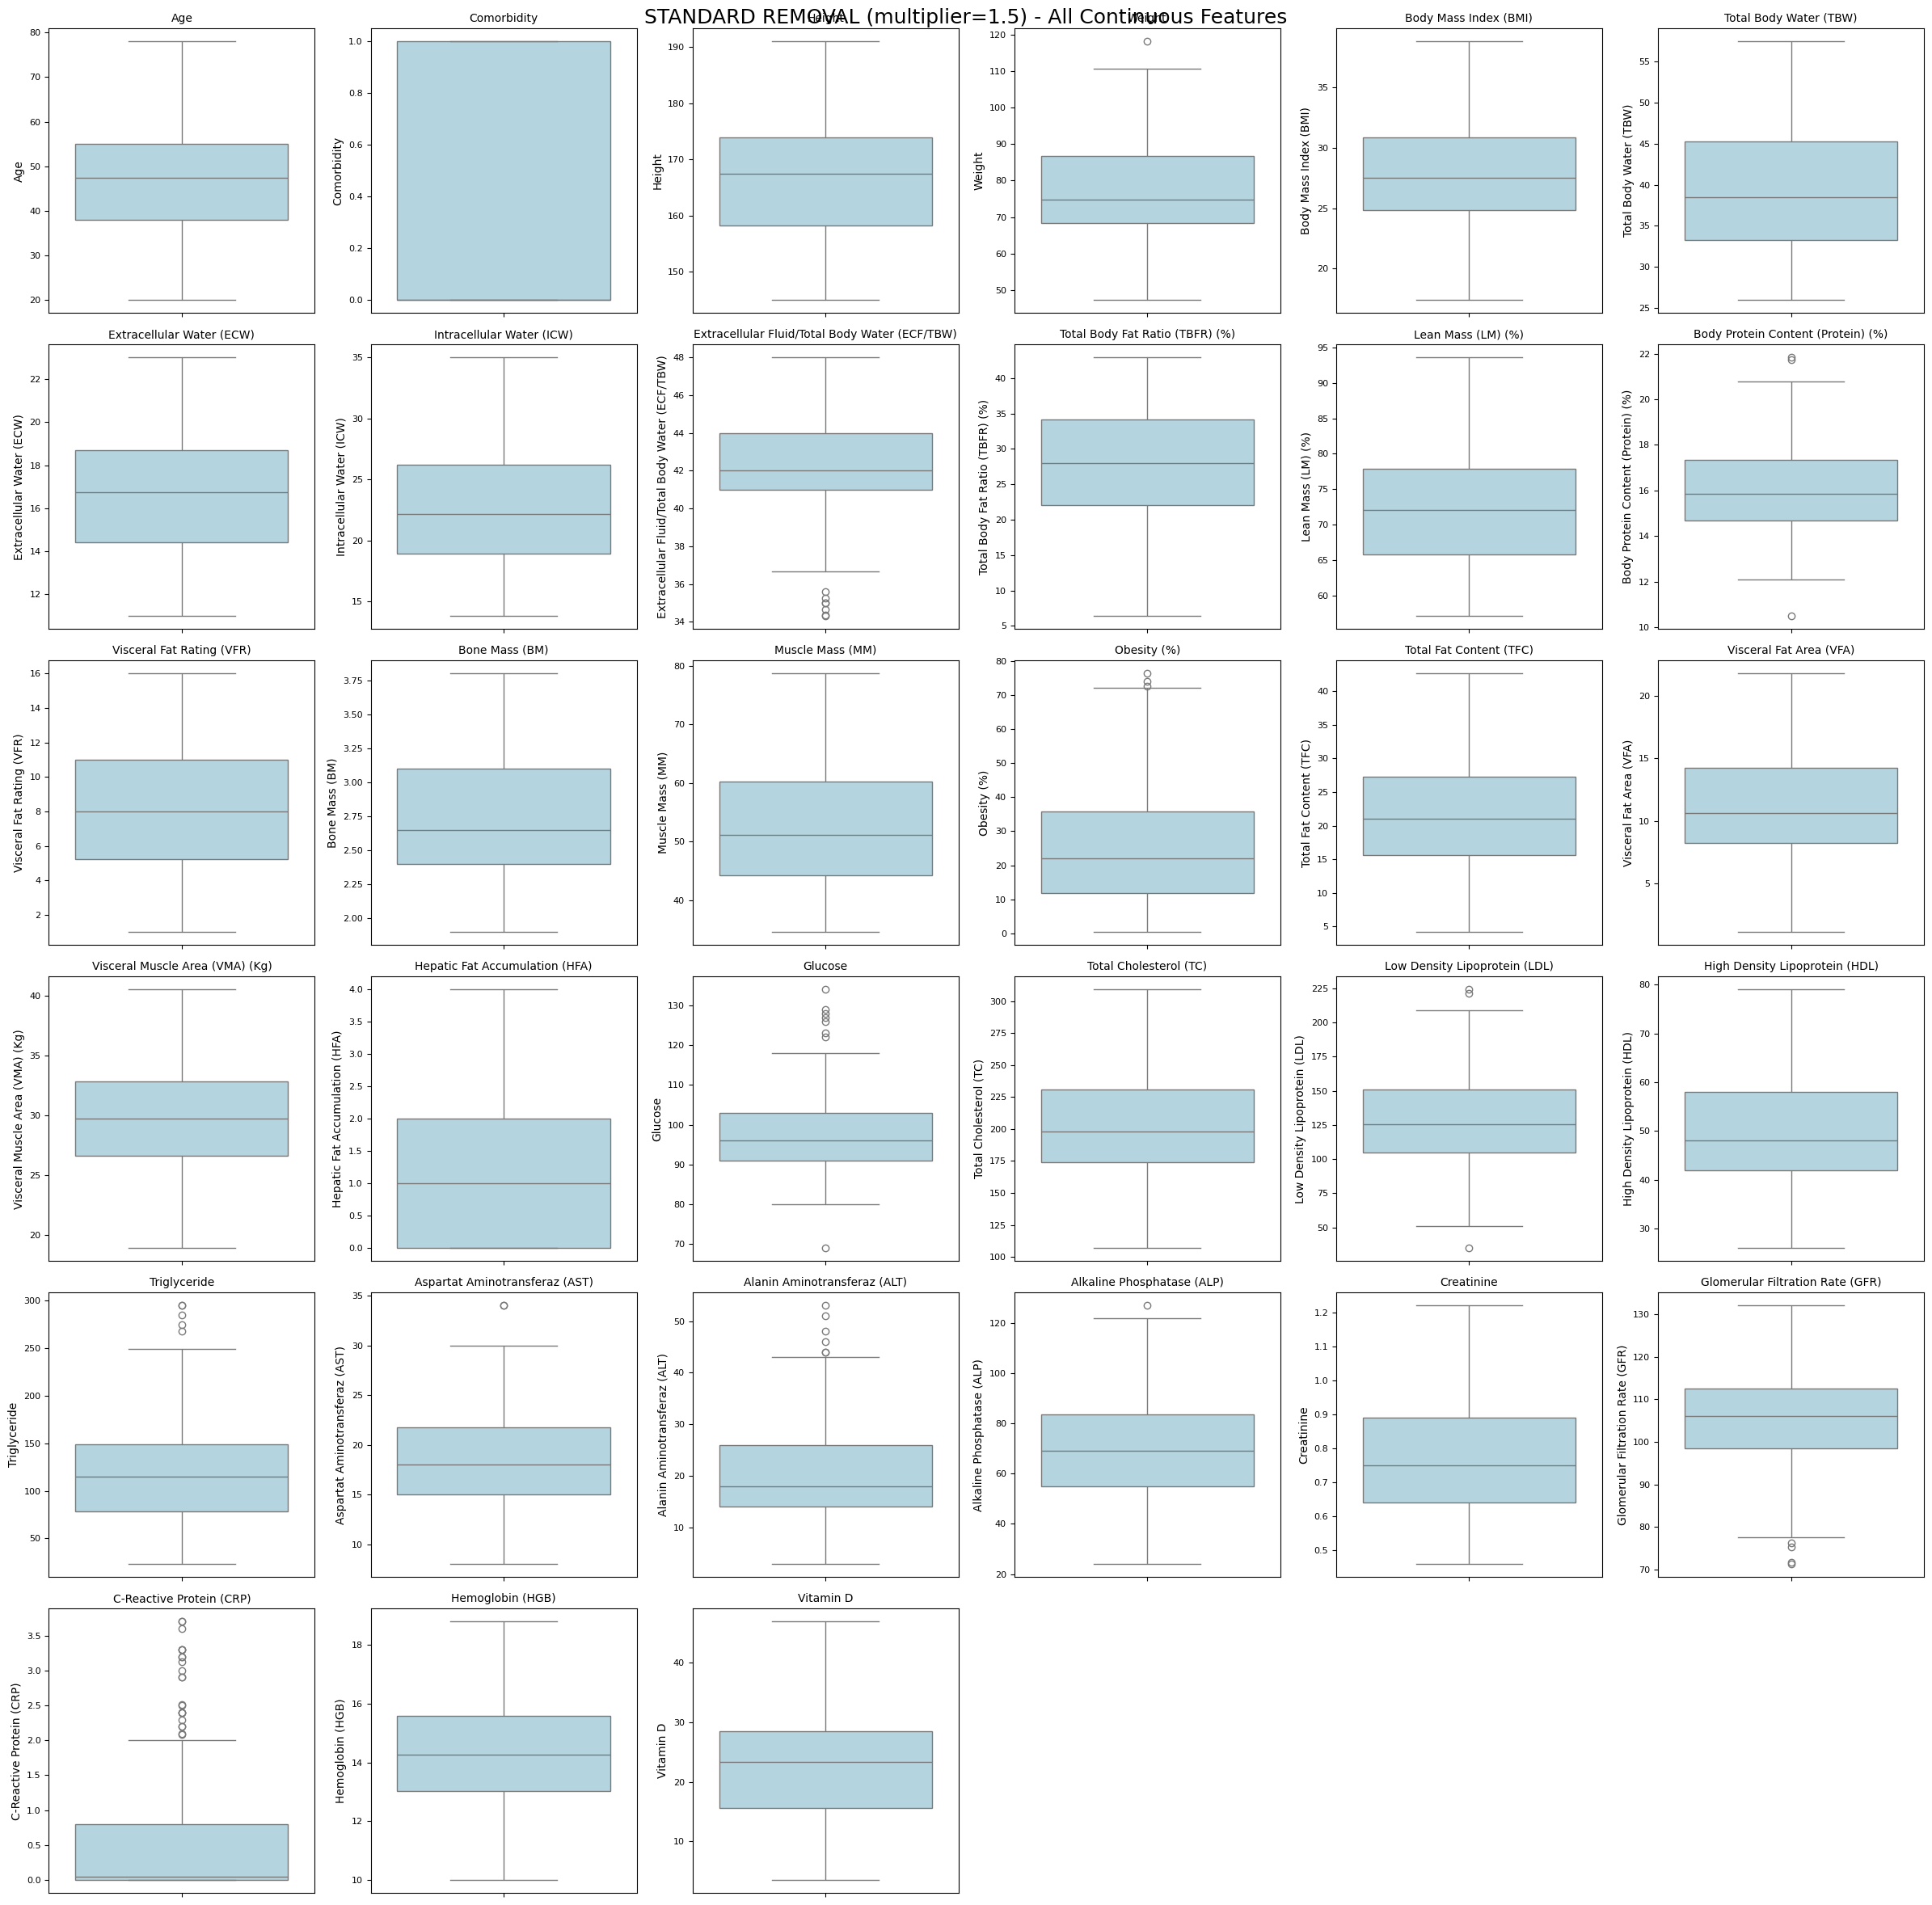

Standard removal: 137 rows removed (42.9%)


In [12]:
# 3. STANDARD REMOVAL - All continuous features
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_features):
    sns.boxplot(y=df_clean_standard[col], ax=axes[i], color="lightblue")
    axes[i].set_title(f"{col}", fontsize=10)
    axes[i].tick_params(axis='both', labelsize=8)

# Hide empty subplots
for j in range(len(plot_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("STANDARD REMOVAL (multiplier=1.5) - All Continuous Features", fontsize=18, y=0.98)
plt.tight_layout()
plt.show()

print(f"Standard removal: {summary_standard['removed_rows']} rows removed ({summary_standard['removal_percentage']:.1f}%)")

C:\Users\larso\AppData\Local\Temp\ipykernel_3556\53385033.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, 0].boxplot(df[feature], labels=['Original'])
C:\Users\larso\AppData\Local\Temp\ipykernel_3556\53385033.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, 1].boxplot(df_clean_conservative[feature], labels=['Conservative'])
C:\Users\larso\AppData\Local\Temp\ipykernel_3556\53385033.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, 2].boxplot(df_clean_standard[feature], labels=['Standard'])
C:\Users\larso\AppData\Local\Temp\ipykernel_3556\53385033.py:15: MatplotlibDeprecationWarning: 

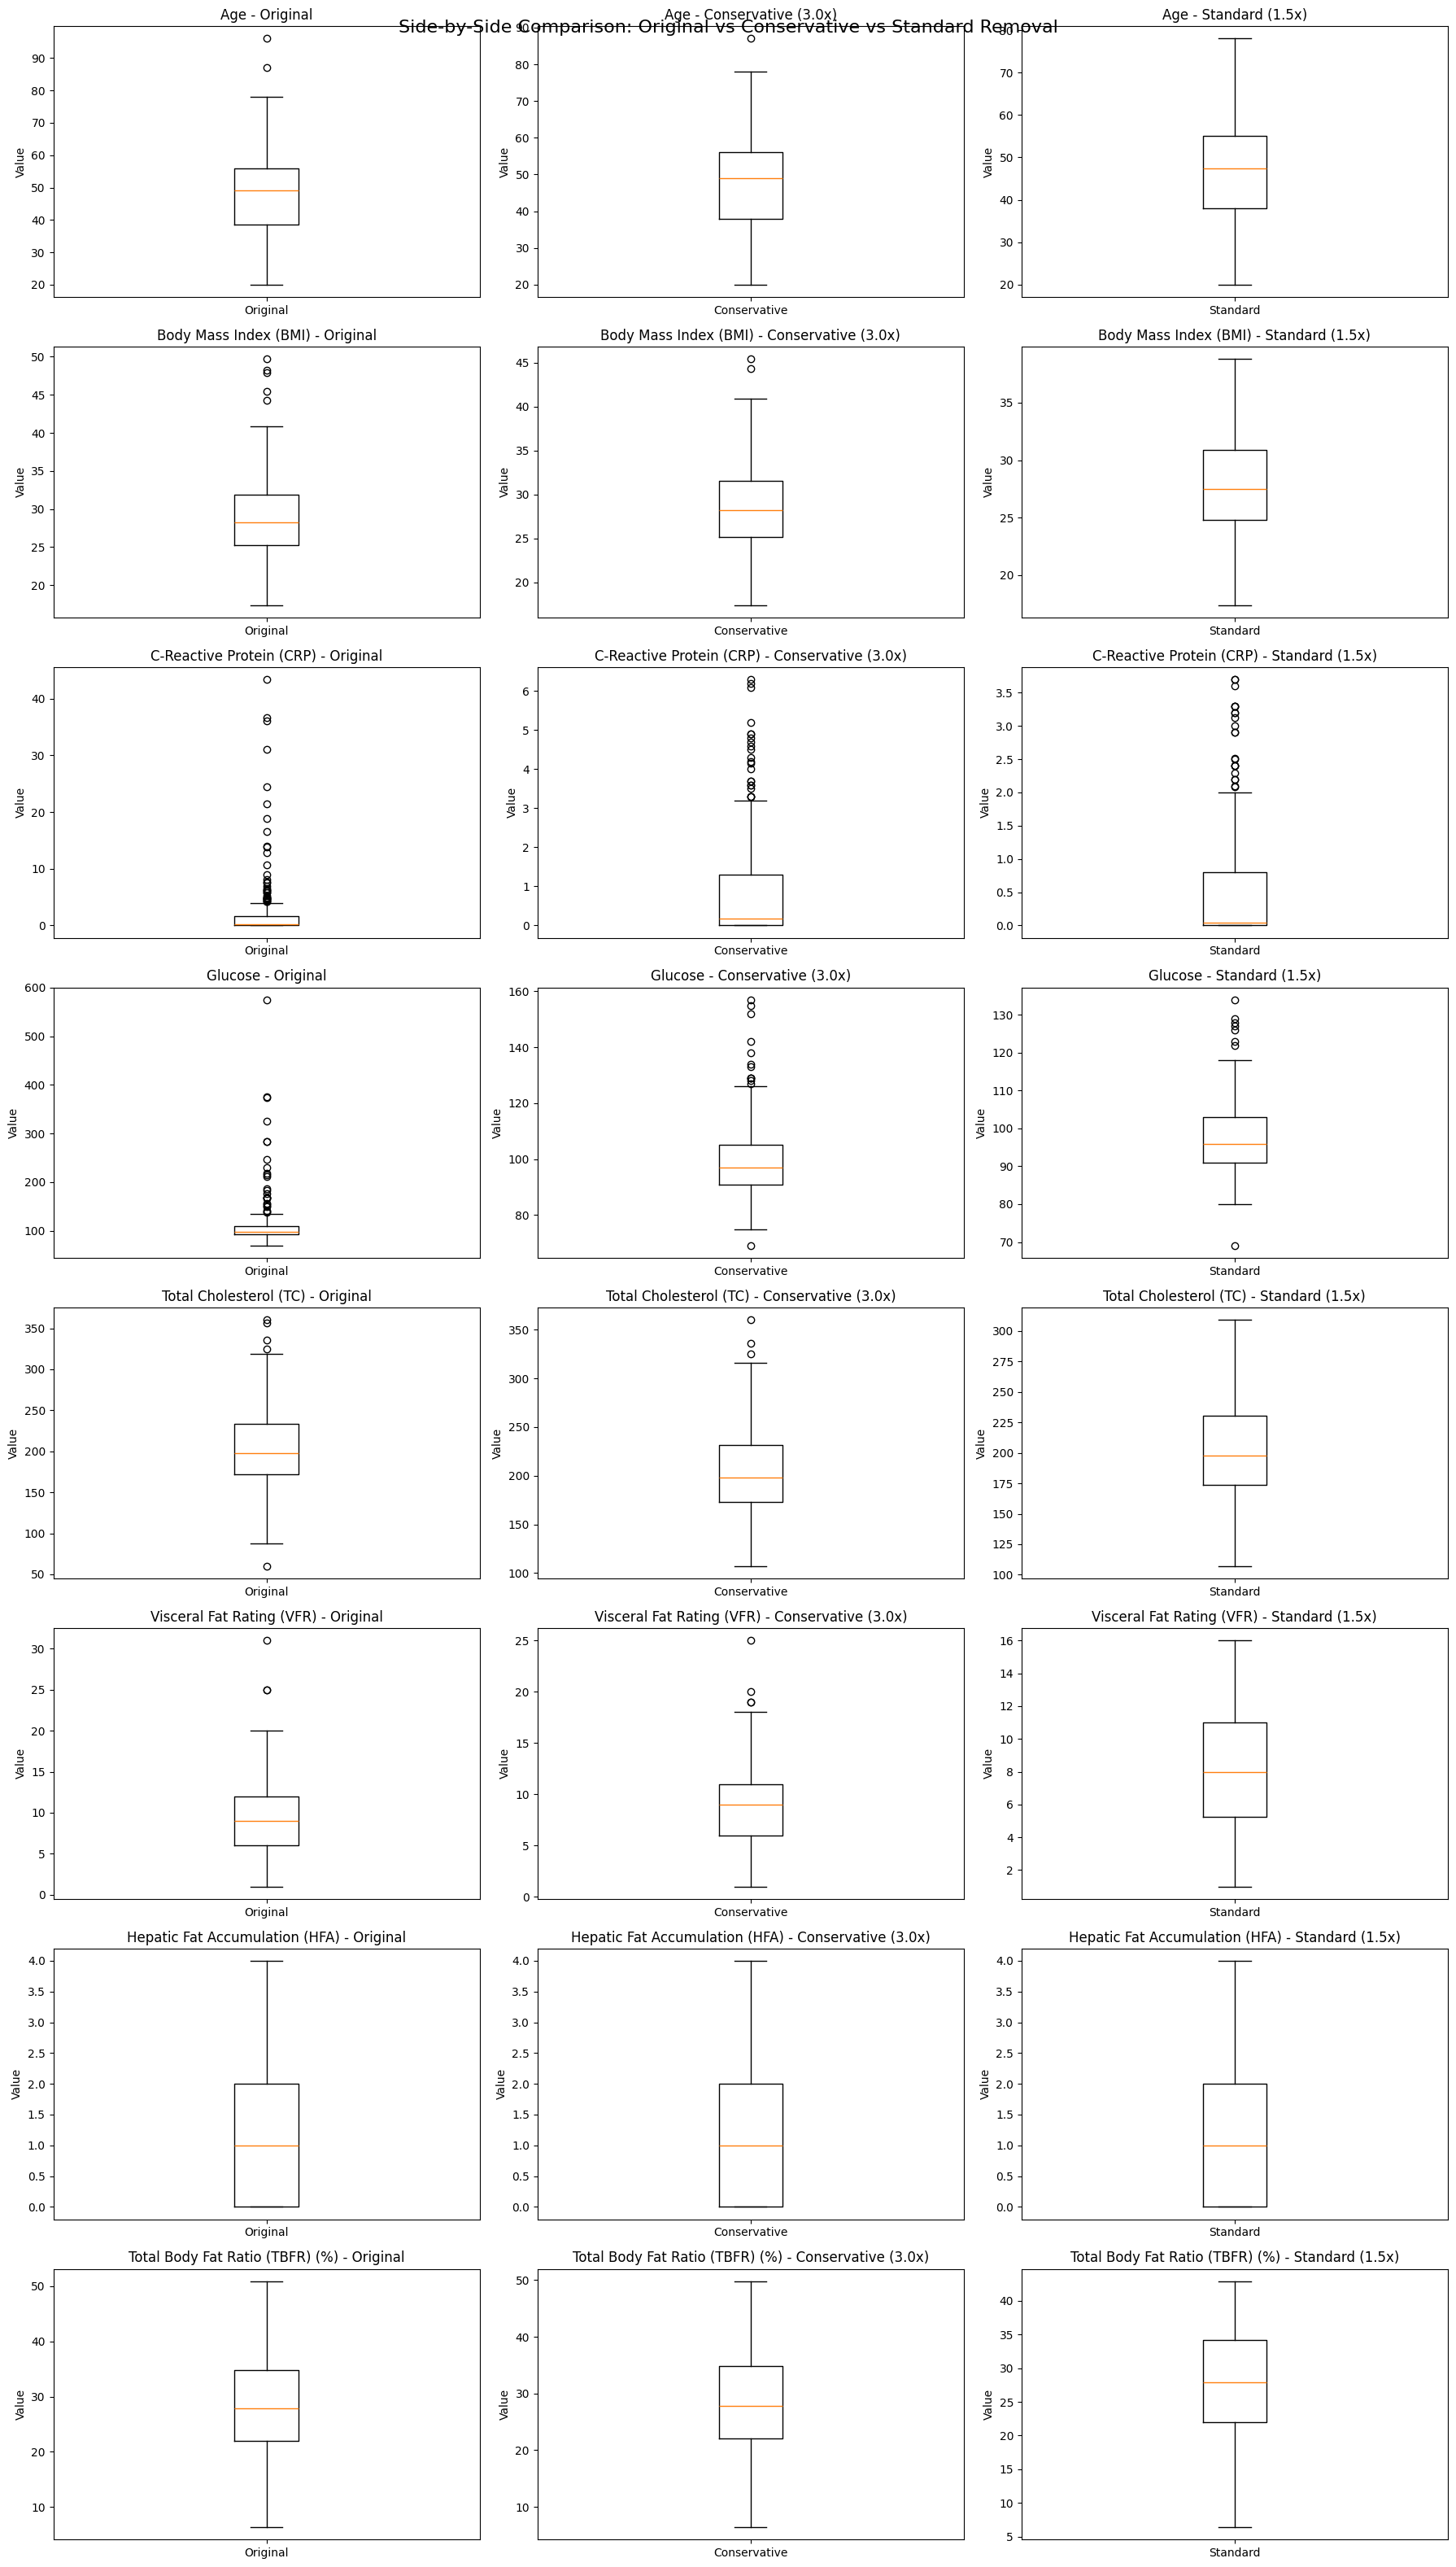

In [13]:
# 4. SIDE-BY-SIDE COMPARISON for selected key features
# Select most important features for detailed comparison
key_features_for_comparison = [
    "Age", "Body Mass Index (BMI)", "C-Reactive Protein (CRP)", 
    "Glucose", "Total Cholesterol (TC)", "Visceral Fat Rating (VFR)",
    "Hepatic Fat Accumulation (HFA)", "Total Body Fat Ratio (TBFR) (%)"
]

# Create side-by-side comparison
n_features = len(key_features_for_comparison)
fig, axes = plt.subplots(n_features, 3, figsize=(18, 4 * n_features))

for i, feature in enumerate(key_features_for_comparison):
    # Original
    axes[i, 0].boxplot(df[feature], labels=['Original'])
    axes[i, 0].set_title(f'{feature} - Original')
    axes[i, 0].set_ylabel('Value')
    
    # Conservative
    axes[i, 1].boxplot(df_clean_conservative[feature], labels=['Conservative'])
    axes[i, 1].set_title(f'{feature} - Conservative (3.0x)')
    axes[i, 1].set_ylabel('Value')
    
    # Standard
    axes[i, 2].boxplot(df_clean_standard[feature], labels=['Standard'])
    axes[i, 2].set_title(f'{feature} - Standard (1.5x)')
    axes[i, 2].set_ylabel('Value')

plt.suptitle('Side-by-Side Comparison: Original vs Conservative vs Standard Removal', fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
# 5. SUMMARY STATISTICS COMPARISON
print("="*80)
print("COMPREHENSIVE OUTLIER REMOVAL COMPARISON SUMMARY")
print("="*80)

print("\n📊 DATASET SIZE COMPARISON:")
print(f"Original dataset:     {df.shape[0]:,} rows")
print(f"Conservative removal: {df_clean_conservative.shape[0]:,} rows (-{summary_conservative['removed_rows']:,} rows, -{summary_conservative['removal_percentage']:.1f}%)")
print(f"Standard removal:     {df_clean_standard.shape[0]:,} rows (-{summary_standard['removed_rows']:,} rows, -{summary_standard['removal_percentage']:.1f}%)")

print(f"\n🎯 CLASS BALANCE COMPARISON:")
original_balance = df['Gallstone Status'].value_counts(normalize=True)
conservative_balance = df_clean_conservative['Gallstone Status'].value_counts(normalize=True)
standard_balance = df_clean_standard['Gallstone Status'].value_counts(normalize=True)

print("Original dataset:")
for status, pct in original_balance.items():
    print(f"  {status}: {pct:.1%}")

print("Conservative removal:")
for status, pct in conservative_balance.items():
    print(f"  {status}: {pct:.1%}")
    
print("Standard removal:")
for status, pct in standard_balance.items():
    print(f"  {status}: {pct:.1%}")

print(f"\n🔍 FEATURES ANALYZED:")
print(f"Continuous features analyzed: {len(continuous_features)}")
print(f"Binary features excluded: {len(binary_features)}")
print(f"Binary features: {binary_features}")

print(f"\n📈 OUTLIER REDUCTION BY FEATURE (Top 10):")
print("Conservative vs Standard removal outlier counts:")

# Show how many outliers remain in each dataset
conservative_remaining = detect_outliers_iqr(df_clean_conservative)
standard_remaining = detect_outliers_iqr(df_clean_standard)

print(f"{'Feature':<30} {'Original':<10} {'Conservative':<12} {'Standard':<10}")
print("-" * 70)

for feature in key_features_for_comparison:
    if feature in outlier_info:
        orig_count = len(outlier_info[feature])
        cons_count = len(conservative_remaining.get(feature, []))
        std_count = len(standard_remaining.get(feature, []))
        print(f"{feature:<30} {orig_count:<10} {cons_count:<12} {std_count:<10}")

COMPREHENSIVE OUTLIER REMOVAL COMPARISON SUMMARY

📊 DATASET SIZE COMPARISON:
Original dataset:     319 rows
Conservative removal: 262 rows (-57 rows, -17.9%)
Standard removal:     182 rows (-137 rows, -42.9%)

🎯 CLASS BALANCE COMPARISON:
Original dataset:
  0: 50.5%
  1: 49.5%
Conservative removal:
  0: 53.1%
  1: 46.9%
Standard removal:
  0: 57.1%
  1: 42.9%

🔍 FEATURES ANALYZED:
Continuous features analyzed: 33
Binary features excluded: 6
Binary features: ['Gallstone Status', 'Gender', 'Coronary Artery Disease (CAD)', 'Hypothyroidism', 'Hyperlipidemia', 'Diabetes Mellitus (DM)']

📈 OUTLIER REDUCTION BY FEATURE (Top 10):
Conservative vs Standard removal outlier counts:
Feature                        Original   Conservative Standard  
----------------------------------------------------------------------
Age                            2          1            0         
Body Mass Index (BMI)          5          2            0         
C-Reactive Protein (CRP)       34         22        

## Analysis Recommendations

Based on the comprehensive box plot comparison above, here are the key insights:

### 🎯 **Visual Comparison Results:**

1. **Red plots (Original)**: Show all outliers - you can see extreme values as individual points beyond the whiskers

2. **Green plots (Conservative, 3.0x)**: Removes only the most extreme outliers while preserving important data points

3. **Blue plots (Standard, 1.5x)**: More aggressive removal, resulting in tighter distributions but potentially losing clinically relevant cases

### 💡 **Recommendation for Medical Data:**

For gallstone prediction using clinical data, I recommend the **Conservative approach (multiplier=3.0)** because:

- **Preserves clinical cases**: Some "extreme" values might represent important medical conditions
- **Maintains sample size**: Less data loss means more statistical power
- **Balanced approach**: Removes truly problematic outliers while keeping borderline cases
- **Class balance**: Better preservation of target variable distribution

The side-by-side comparison clearly shows how each method affects your data distribution!

## Save Cleaned Datasets

Let's save both the conservative and standard cleaned datasets to CSV files for future use.

In [16]:
# Save the cleaned datasets to CSV files
import os

# Create data directory if it doesn't exist
data_dir = "../data"
if not os.path.exists(data_dir):
    os.makedirs(data_dir)
    print(f"Created directory: {data_dir}")

# Save conservative cleaned dataset
conservative_filename = "gallstone_data_conservative_cleaned.csv"
conservative_path = os.path.join(data_dir, conservative_filename)
df_clean_conservative.to_csv(conservative_path, index=False)

# Save standard cleaned dataset  
standard_filename = "gallstone_data_standard_cleaned.csv"
standard_path = os.path.join(data_dir, standard_filename)
df_clean_standard.to_csv(standard_path, index=False)


print("="*60)
print("📁 DATASETS SAVED SUCCESSFULLY!")
print("="*60)
print()
print(f"✅ Conservative cleaned: {conservative_path}")
print(f"   └── Shape: {df_clean_conservative.shape[0]:,} rows × {df_clean_conservative.shape[1]} columns")
print(f"   └── Removed: {summary_conservative['removed_rows']:,} rows ({summary_conservative['removal_percentage']:.1f}%)")
print()
print(f"✅ Standard cleaned:     {standard_path}")
print(f"   └── Shape: {df_clean_standard.shape[0]:,} rows × {df_clean_standard.shape[1]} columns")
print(f"   └── Removed: {summary_standard['removed_rows']:,} rows ({summary_standard['removal_percentage']:.1f}%)")
print()
print("💡 Recommendations:")
print("   • Use CONSERVATIVE dataset for initial modeling (preserves more clinical cases)")
print("   • Use STANDARD dataset if you need more aggressive outlier removal")
print("   • Original dataset available for reference and comparison")

📁 DATASETS SAVED SUCCESSFULLY!

✅ Conservative cleaned: ../data\gallstone_data_conservative_cleaned.csv
   └── Shape: 262 rows × 39 columns
   └── Removed: 57 rows (17.9%)

✅ Standard cleaned:     ../data\gallstone_data_standard_cleaned.csv
   └── Shape: 182 rows × 39 columns
   └── Removed: 137 rows (42.9%)

💡 Recommendations:
   • Use CONSERVATIVE dataset for initial modeling (preserves more clinical cases)
   • Use STANDARD dataset if you need more aggressive outlier removal
   • Original dataset available for reference and comparison


In [17]:
# Create summary metadata for the saved datasets
metadata = {
    'conservative': {
        'filename': conservative_filename,
        'path': conservative_path,
        'shape': df_clean_conservative.shape,
        'description': 'Conservative outlier removal (3.0x IQR multiplier)',
        'outlier_removal': 'Conservative (multiplier=3.0)',
        'rows_removed': summary_conservative['removed_rows'],
        'removal_percentage': summary_conservative['removal_percentage'],
        'binary_features_preserved': True,
        'binary_features_excluded': summary_conservative['binary_features_excluded'],
        'features_analyzed': len(summary_conservative['features_analyzed'])
    },
    'standard': {
        'filename': standard_filename,
        'path': standard_path,
        'shape': df_clean_standard.shape,
        'description': 'Standard outlier removal (1.5x IQR multiplier)',
        'outlier_removal': 'Standard (multiplier=1.5)',
        'rows_removed': summary_standard['removed_rows'],
        'removal_percentage': summary_standard['removal_percentage'],
        'binary_features_preserved': True,
        'binary_features_excluded': summary_standard['binary_features_excluded'],
        'features_analyzed': len(summary_standard['features_analyzed'])
    }
}

# Save metadata as JSON for reference
import json
metadata_path = os.path.join(data_dir, "datasets_metadata.json")
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"📋 Metadata saved: {metadata_path}")
print("\n🔍 Quick access guide:")
print("   • Load conservative: pd.read_csv('../data/gallstone_data_conservative_cleaned.csv')")
print("   • Load standard:     pd.read_csv('../data/gallstone_data_standard_cleaned.csv')")

# Verify class balance is maintained in saved files
print("\n✅ Class balance verification:")
print("Conservative:", df_clean_conservative['Gallstone Status'].value_counts(normalize=True).to_dict())
print("Standard:", df_clean_standard['Gallstone Status'].value_counts(normalize=True).to_dict())

📋 Metadata saved: ../data\datasets_metadata.json

🔍 Quick access guide:
   • Load conservative: pd.read_csv('../data/gallstone_data_conservative_cleaned.csv')
   • Load standard:     pd.read_csv('../data/gallstone_data_standard_cleaned.csv')

✅ Class balance verification:
Conservative: {0: 0.5305343511450382, 1: 0.46946564885496184}
Standard: {0: 0.5714285714285714, 1: 0.42857142857142855}


In [5]:
class GallstoneDataProcessor:
    def __init__(self, data_path):
        """Initialize the processor with the dataset path."""
        self.data_path = data_path
        self.df = pd.read_csv(data_path, low_memory=False)
        self.filter_log = []

    def preprocess_data(self, output_path):
        """ Encode categorical variables and scale numerical features."""
        df_encoded = self.df.copy()

        # Identify categorical columns
        categorical_cols = df_encoded.select_dtypes(include=['object']).columns
        print(f"Categorical columns identified for encoding: {categorical_cols.tolist()}")

        # Create label encoders for each categorical column
        label_encoders = {}
        for col in categorical_cols:
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
            label_encoders[col] = le
            print(f"Encoded column '{col}' with labels: {le.classes_}")
        
        # Normalize/scalar numeric features
        # First column is the target
        feature_cols = df_encoded.columns[1:]
        target_col = df_encoded.columns[0]

        print(f"Feature columns: {list(feature_cols)}")
        print(f"Target column: {target_col}")

        # Separate features and target
        X = df_encoded[feature_cols]
        y = df_encoded[target_col]

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Convert back to DataFrame for better readability
        df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

        # Combine scaled features with target
        df_final = pd.concat([y.reset_index(drop=True), df_scaled], axis=1)
        self.df = df_final
        print("Data preprocessing completed: categorical encoding and feature scaling applied.")

        # Save the processed data
        self.df.to_csv(output_path, index=False)
        print(f"Preprocessed data saved to {output_path}.")
        

    def stratified_train_test_split(self, output_path):
        """Perform a stratified train-test split based on the 'Gallstone Status' column."""
        
        # Perform stratified split
        train_df, test_df = train_test_split(
            self.df,
            test_size=0.2,
            stratify=self.df['Gallstone Status'],
            random_state=42
        )

        # Store the resulting dataframes 

        # Assign train/test labels to df
        self.df['Set'] = np.where(self.df.index.isin(train_df.index), 'train', 'test')

        # Save to CSV
        self.df.to_csv(output_path, index=False)
        print(f"Stratified train-test split completed. Data saved to {output_path}.")
    

In [6]:
# Initiate and execute
processor = GallstoneDataProcessor('data/dataset-uci.csv')
processor.preprocess_data('data/gallstone_data_preprocessed.csv')
processor.stratified_train_test_split('data/gallstone_data_train_test_split.csv')

Categorical columns identified for encoding: []
Feature columns: ['Age', 'Gender', 'Comorbidity', 'Coronary Artery Disease (CAD)', 'Hypothyroidism', 'Hyperlipidemia', 'Diabetes Mellitus (DM)', 'Height', 'Weight', 'Body Mass Index (BMI)', 'Total Body Water (TBW)', 'Extracellular Water (ECW)', 'Intracellular Water (ICW)', 'Extracellular Fluid/Total Body Water (ECF/TBW)', 'Total Body Fat Ratio (TBFR) (%)', 'Lean Mass (LM) (%)', 'Body Protein Content (Protein) (%)', 'Visceral Fat Rating (VFR)', 'Bone Mass (BM)', 'Muscle Mass (MM)', 'Obesity (%)', 'Total Fat Content (TFC)', 'Visceral Fat Area (VFA)', 'Visceral Muscle Area (VMA) (Kg)', 'Hepatic Fat Accumulation (HFA)', 'Glucose', 'Total Cholesterol (TC)', 'Low Density Lipoprotein (LDL)', 'High Density Lipoprotein (HDL)', 'Triglyceride', 'Aspartat Aminotransferaz (AST)', 'Alanin Aminotransferaz (ALT)', 'Alkaline Phosphatase (ALP)', 'Creatinine', 'Glomerular Filtration Rate (GFR)', 'C-Reactive Protein (CRP)', 'Hemoglobin (HGB)', 'Vitamin D']
T